<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Flexão de vigas constituídas por vários materiais.

### Problema 4

Uma viga de madeira com secção transversal de 120 $\times$ 160 mm $^2$ foi reforçada com duas barras de aço de secção 100 $\times$ 10 mm $^2$ como indicado na figura. O módulo de elasticidade da madeira é de 10 GPa e o do aço é 210 GPa. Sabendo que a viga se encontra fletida em torno de um eixo horizontal devido à atuação de um momento fletor igual a 22 kN.m, represente a distribuição de tensões normais na madeira e no aço e determine o valor da tensão normal máxima em cada um desses dois materiais.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au02/P4/MSII_Au02_P4.png"
width="800" />

### Resolução

 Wood section :    120.0 mm x 160.0 mm = 19200.0 mm²
Steel section : 2x(100.0 mm x 10.0) mm = 1000.0   mm²


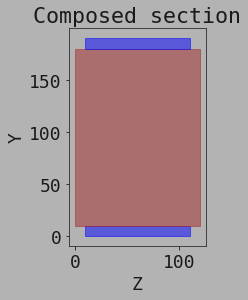

In [203]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)


# data structure, units: SI: kN, m
class varin: pass
Wood = varin()  # Create an empty class
Steel = varin()
S = varin()

# units: N, m, Pa
Wood.E = 10e3 # MPa
Steel.E = 210e3 # MPa
Mf = 22e6 # kN.m = N.mm (1e3.1e3)
S.lw = 120 # mm
S.hw = 160 # mm
S.ls = 100 # mm
S.hs = 10 # mm

S.Aw = S.lw*S.hw
print(f' Wood section :    {S.lw:.1f} mm x {S.hw:.1f} mm = {S.Aw:.1f} mm²')
S.As = S.ls*S.hs
print(f'Steel section : 2x({S.ls:.1f} mm x {S.hs:.1f}) mm = {S.As:.1f}   mm²')

from matplotlib.patches import Rectangle

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle(((S.lw-S.ls)/2, 0), S.ls, S.hs,color="blue",alpha=0.5))
ax.add_patch(Rectangle((0, S.hs), S.lw, S.hs+S.hw,color="brown",alpha=0.5))
ax.add_patch(Rectangle(((S.lw-S.ls)/2, 2*S.hs+S.hw), S.ls, S.hs,color="blue",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Composed section")
ax.set_aspect('equal')
plt.show()

### Secção transversal homogénea de aço

A transformação da região de madeira em aço pode ser obtida usando o seguinte rácio material:

\begin{equation*}
n = \frac{E_\mathrm{w}}{E_\mathrm{s}}
\end{equation*}

n = Es/Ew = 0.048 
ls2w = n*l = 5.714 


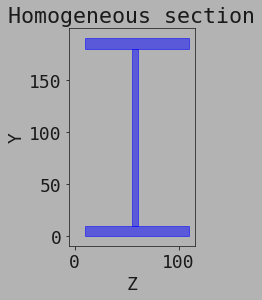

In [204]:
S.n = Wood.E/Steel.E
print(f'n = Es/Ew = {S.n:.3f} ')

print(f'ls2w = n*l = {S.n*S.lw:.3f} ')

fig, ax = plt.subplots()
ax.plot([0],[0],color="black")
ax.add_patch(Rectangle(((S.lw-S.ls)/2, 0), S.ls, S.hs,color="blue",alpha=0.5))
ax.add_patch(Rectangle(((S.lw+S.ls)/4, S.hs), S.lw*S.n, S.hs+S.hw,color="blue",alpha=0.5))
ax.add_patch(Rectangle(((S.lw-S.ls)/2, 2*S.hs+S.hw), S.ls, S.hs,color="blue",alpha=0.5))
plt.xlabel("Z")
plt.ylabel("Y")
plt.title("Homogeneous section")
ax.set_aspect('equal')
plt.show()

- Centroíde da secção

Esta nova geometria para a secção transversal tem dupla simetria pelo que a posição do centróide de secção não é alterado pela trnsformação homogénea.

\begin{equation*}
\overline{y} = \sum_i \frac{A_i\overline{y}_i}{A_i}
\quad\Rightarrow\quad
\overline{y} = \frac{\sum_{i=1}^{2} A_\textrm{i}\overline{y}_\textrm{i}\Big|_\textrm{Aco} + n A_\textrm{Al}\overline{y}_\textrm{Al}}{\sum_{i=1}^{2} A_\textrm{i}\Big|_\textrm{Aco} + n A_\textrm{Al}}
\end{equation*}

In [205]:
S.ys1 = S.hs/2
S.yw = S.hs+S.hw/2
S.ys2 = S.hs+S.hw+S.hs/2

S.ytot = (S.ys1*S.As + (S.yw*S.Aw)*S.n + S.ys2*S.As)/(2*S.As + S.Aw*S.n)
print(f'Ay steel = {S.ys1*S.As:.2f} mm³')
print(f'Ay wood = {S.yw*S.As*S.n:.2f} mm³')
print(f'y transformed section = {S.ytot:.2f} mm³ | htot/2 = {(2*S.hs+S.hw)/2} mm³')

Ay steel = 5000.00 mm³
Ay wood = 4285.71 mm³
y transformed section = 90.00 mm³ | htot/2 = 90.0 mm³


- Momento de inércia de área

O momento de inércia da secção transformada pode também ser obtido pela combinação linear dos momentos de inércia das regiões elementares da secção:

\begin{equation*}
I_t = \sum_{i=1}^{2}I_\textrm{i}\Big|_{\textrm{st}} + nI_\textrm{w} = 2(\underbrace{\overline{I}_1 + A_1 d_1²}_{\textrm{st 1}}) + \underbrace{n(\overline{I}_2)}_{\textrm{w}}
\end{equation*}

In [206]:
def irect(b,h): return b*h**3/12

d1 = S.ytot-S.ys1
print(f'd1   : {d1} mm')
Ic1 = irect(S.ls,S.hs)
print(f'Ic.s : {Ic1:.2f} mm⁴')
S.Is = Ic1 + S.As*d1**2
print(f'S.Is = {S.Is:.2f} mm⁴')

S.Iw = irect(S.lw*S.n,S.hw)
print(f'S.Iw = {S.Iw:.2f} mm⁴')

S.Itot = 2*S.Is + S.Iw
print(f'S.Itot = {S.Itot:.2f} mm⁴')

d1   : 85.0 mm
Ic.s : 8333.33 mm⁴
S.Is = 7233333.33 mm⁴
S.Iw = 1950476.19 mm⁴
S.Itot = 16417142.86 mm⁴


- Aço:

\begin{equation*}
\sigma = -\frac{M_f}{I_t}y
\end{equation*}

- Madeira:

\begin{equation*}
\sigma= -n\left(\frac{M_f}{I_t}y\right)
\end{equation*}

In [207]:
def sval(m,i,y):
    return -m/i*y

# (i) steel
yp1 = -S.ytot
sp1 = sval(Mf,S.Itot,yp1)
print(f'Steel : y1 = {yp1:.2f} mm | S(y1)  = {sp1:.2f} MPa')

# (ii) steel
yp2 = -S.ytot + S.hs
sp2 = sval(Mf,S.Itot,yp2)
print(f'      : y2 = {yp2:.2f} mm | S(y2)  = {sp2:.2f} MPa')

# (iii) wood
yp3 = yp2
sp3 = sval(Mf,S.Itot,yp3*S.n)
print(f'      : y3 = {yp3:.2f} mm | S(y3)  = {sp3:.2f} MPa')

# (iii) wood
yp4 = -S.ytot + S.hs + S.hw
sp4 = sval(Mf,S.Itot,yp4)*S.n
print(f'Wood  : y4 = {yp4:.2f} mm  | S(y4)  = {sp4:.2f} MPa')

# (iv) steel
yp5 = yp4
sp5 = sval(Mf,S.Itot,yp5)
print(f'      : y5 = {yp5:.2f} mm  | S(y5)  = {sp5:.2f} MPa')

# (v) steel
yp6 = 2*S.hs + S.hw - S.ytot
sp6 = sval(Mf,S.Itot,yp6)
print(f'      : y6 = {yp6:.2f} mm  | S(y6)  = {sp6:.2f} MPa')

Steel : y1 = -90.00 mm | S(y1)  = 120.61 MPa
      : y2 = -80.00 mm | S(y2)  = 107.21 MPa
      : y3 = -80.00 mm | S(y3)  = 5.11 MPa
Wood  : y4 = 80.00 mm  | S(y4)  = -5.11 MPa
      : y5 = 80.00 mm  | S(y5)  = -107.21 MPa
      : y6 = 90.00 mm  | S(y6)  = -120.61 MPa


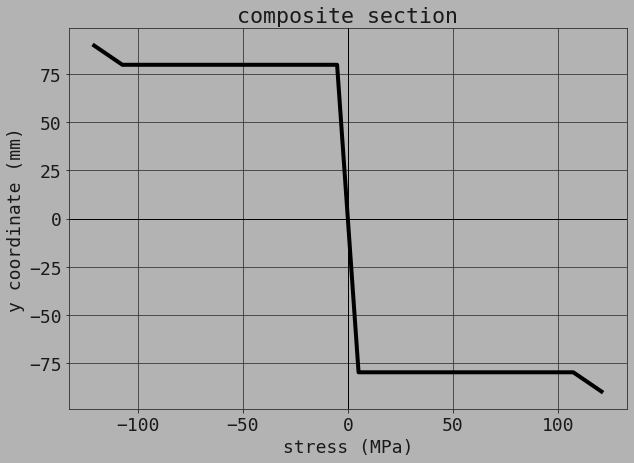

In [208]:
xplo = [yp1,yp2,yp3,yp4,yp5,yp6]
yplo = [sp1,sp2,sp3,sp4,sp5,sp6]

fz = 15
fig, ax = plt.subplots(figsize=(10,7))
plt.plot(yplo,xplo,'-k', linewidth=4)
plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
plt.title('composite section')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()
plt.show()

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>